# Machine Failure Prediction Analysis

Machine failure is any unplanned event where industrial equipment stops performing its required function, ranging from a minor performance drop to a complete breakdown that halts the entire production line.

### Importing librabries and defining project theme

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             precision_recall_curve, average_precision_score)
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
from lifelines import KaplanMeierFitter, WeibullAFTFitter
from lifelines.utils import survival_table_from_events
import warnings
warnings.filterwarnings("ignore")



sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:.4f}".format)

# DEFINE

### Business Problem
Unplanned machine downtime is one of the most expensive operational risks in manufacturing. When a machine fails unexpectedly, production halts, maintenance crews respond reactively, spare parts must be sourced urgently, and delivery commitments are missed.

### Problem statement

The factory operates 7 critical machines monitored by IoT sensors every 2 hours. Despite rich sensor data, the maintenance team has no predictive model to anticipate
failures, they rely on fixed schedules and reactive repairs.

### Goal

Build a predictive model that identifies which machine is most likely to malfunction within the next 7 days, enabling the maintenance team to intervene proactively and minimize downtime risk.

# MEASURE

**machine_id:** Unique identifier for each of the 7 machines (M001–M007).

**timestamp:** Datetime of the sensor reading, logged every 2 hours from Monday to Monday.

**temperature:** Machine surface temperature in Celsius.

**continuous_days_running:** Number of consecutive days the machine has been running without shutdown.

**days_since_checking:** Number of consecutive days since the last technician inspection.

**power_consumption:** Electrical power draw in watts.

**vibration_level:** Vibration intensity measured by accelerometer.

**noise_level:** Ambient and operational noise level in decibels.

**rpm:** Rotational speed of the machine spindle in RPM.

**humidity:** Environmental humidity percentage.

**malfunction:** Binary malfunction label (1 = confirmed malfunction event, 0 = normal operation).

### Dataset uploaded

In [2]:
df = pd.read_csv("predictive_maintenance.csv", parse_dates=["timestamp"])
df

,machine_id,timestamp,temperature,continuous_days_running,days_since_checking,power_consumption,vibration_level,noise_level,rpm,humidity,malfunction
0,M001,2024-01-01 00:00:00,64.1300,0.0000,0.0000,583.3500,1.8550,79.8000,2673.6000,76.2900,1
1,M001,2024-01-01 02:00:00,64.4400,0.0833,0.0833,578.8000,1.7840,79.2400,2681.1000,53.2000,0
2,M001,2024-01-01 04:00:00,63.3800,0.1667,0.1667,613.9100,0.1870,72.4100,2757.5000,56.1000,1
3,M001,2024-01-01 06:00:00,63.6900,0.2500,0.2500,567.8300,0.7680,67.8900,2608.6000,72.3800,0
4,M001,2024-01-01 08:00:00,65.8900,0.3333,0.3333,582.6400,3.5240,70.3200,2695.6000,65.9000,0
...,...,...,...,...,...,...,...,...,...,...,...
2354,M007,2024-01-28 16:00:00,84.1900,12.0833,12.0833,475.4000,3.4870,84.8100,2695.7000,64.0700,0
2355,M007,2024-01-28 18:00:00,87.2000,12.1667,12.1667,483.3400,4.2850,91.6000,3159.5000,52.9500,0
2356,M007,2024-01-28 20:00:00,81.8100,12.2500,12.2500,487.5600,1.4750,86.9500,3069.7000,59.2500,0
2357,M007,2024-01-28 22:00:00,85.9400,12.3333,12.3333,480.8200,4.4480,65.2100,2947.4000,79.2300,0


# ANALYZE

### Getting basic information from dataset

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
df.describe()

=== dtypes ===
machine_id                         object
timestamp                  datetime64[ns]
temperature                       float64
continuous_days_running           float64
days_since_checking               float64
power_consumption                 float64
vibration_level                   float64
noise_level                       float64
rpm                               float64
humidity                          float64
malfunction                         int64
dtype: object

=== Missing values ===
machine_id                 0
timestamp                  0
temperature                0
continuous_days_running    0
days_since_checking        0
power_consumption          0
vibration_level            0
noise_level                0
rpm                        0
humidity                   0
malfunction                0
dtype: int64

=== Basic Stats ===


,timestamp,temperature,continuous_days_running,days_since_checking,power_consumption,vibration_level,noise_level,rpm,humidity,malfunction
count,2359,2359.0000,2359.0000,2359.0000,2359.0000,2359.0000,2359.0000,2359.0000,2359.0000,2359.0000
mean,2024-01-15 00:00:00,71.3744,7.4297,6.9965,449.5256,2.3525,75.0987,2288.1687,55.5266,0.0157
min,2024-01-01 00:00:00,51.0000,0.0000,0.0000,126.1100,0.0000,48.8200,1157.8000,19.5000,0.0000
25%,2024-01-08 00:00:00,65.2450,2.9167,2.7500,333.5150,1.2695,65.2350,1805.2000,43.2250,0.0000
50%,2024-01-15 00:00:00,70.4700,7.1667,6.5000,472.5400,2.3830,75.2700,2331.2000,55.6200,0.0000
75%,2024-01-22 00:00:00,78.3750,11.3333,11.0000,550.3000,3.4315,85.0700,2809.6500,68.2100,0.0000
max,2024-01-29 00:00:00,106.0600,18.5000,17.1667,765.2500,5.0280,103.0400,3277.3000,90.7000,1.0000
std,NaN,8.9326,4.9257,4.7371,109.2232,1.2797,11.8642,556.4176,14.8364,0.1243


### Malfunction Summary by Machine

In [4]:
summary = (df.groupby("machine_id")
           .agg(
               total_readings=("malfunction", "count"),
               malfunctions=("malfunction", "sum"),
               malfunction_rate=("malfunction", "mean"),
               avg_temperature=("temperature", "mean"),
               avg_days_running=("continuous_days_running", "mean"),
               avg_days_since_check=("days_since_checking", "mean"),
           )
           .round(4)
           .reset_index())
print(f"Overall malfunction rate: {df.malfunction.mean():.2%}")
print(f"Total malfunction events: {df.malfunction.sum()}\n")
summary


Overall malfunction rate: 1.57%
Total malfunction events: 37



,machine_id,total_readings,malfunctions,malfunction_rate,avg_temperature,avg_days_running,avg_days_since_check
0,M001,337,7,0.0208,66.8676,5.3479,5.3479
1,M002,337,3,0.0089,58.1274,6.9498,7.1338
2,M003,337,3,0.0089,80.4462,6.7752,7.2559
3,M004,337,7,0.0208,74.0786,8.3838,5.7962
4,M005,337,6,0.0178,66.4501,9.2596,9.2596
5,M006,337,4,0.0119,70.4077,6.8838,7.5663
6,M007,337,7,0.0208,83.2435,8.4080,6.6157


### Sensor Time Series per Machine: Temperature (blue) & Power (orange) with a malfuction signal

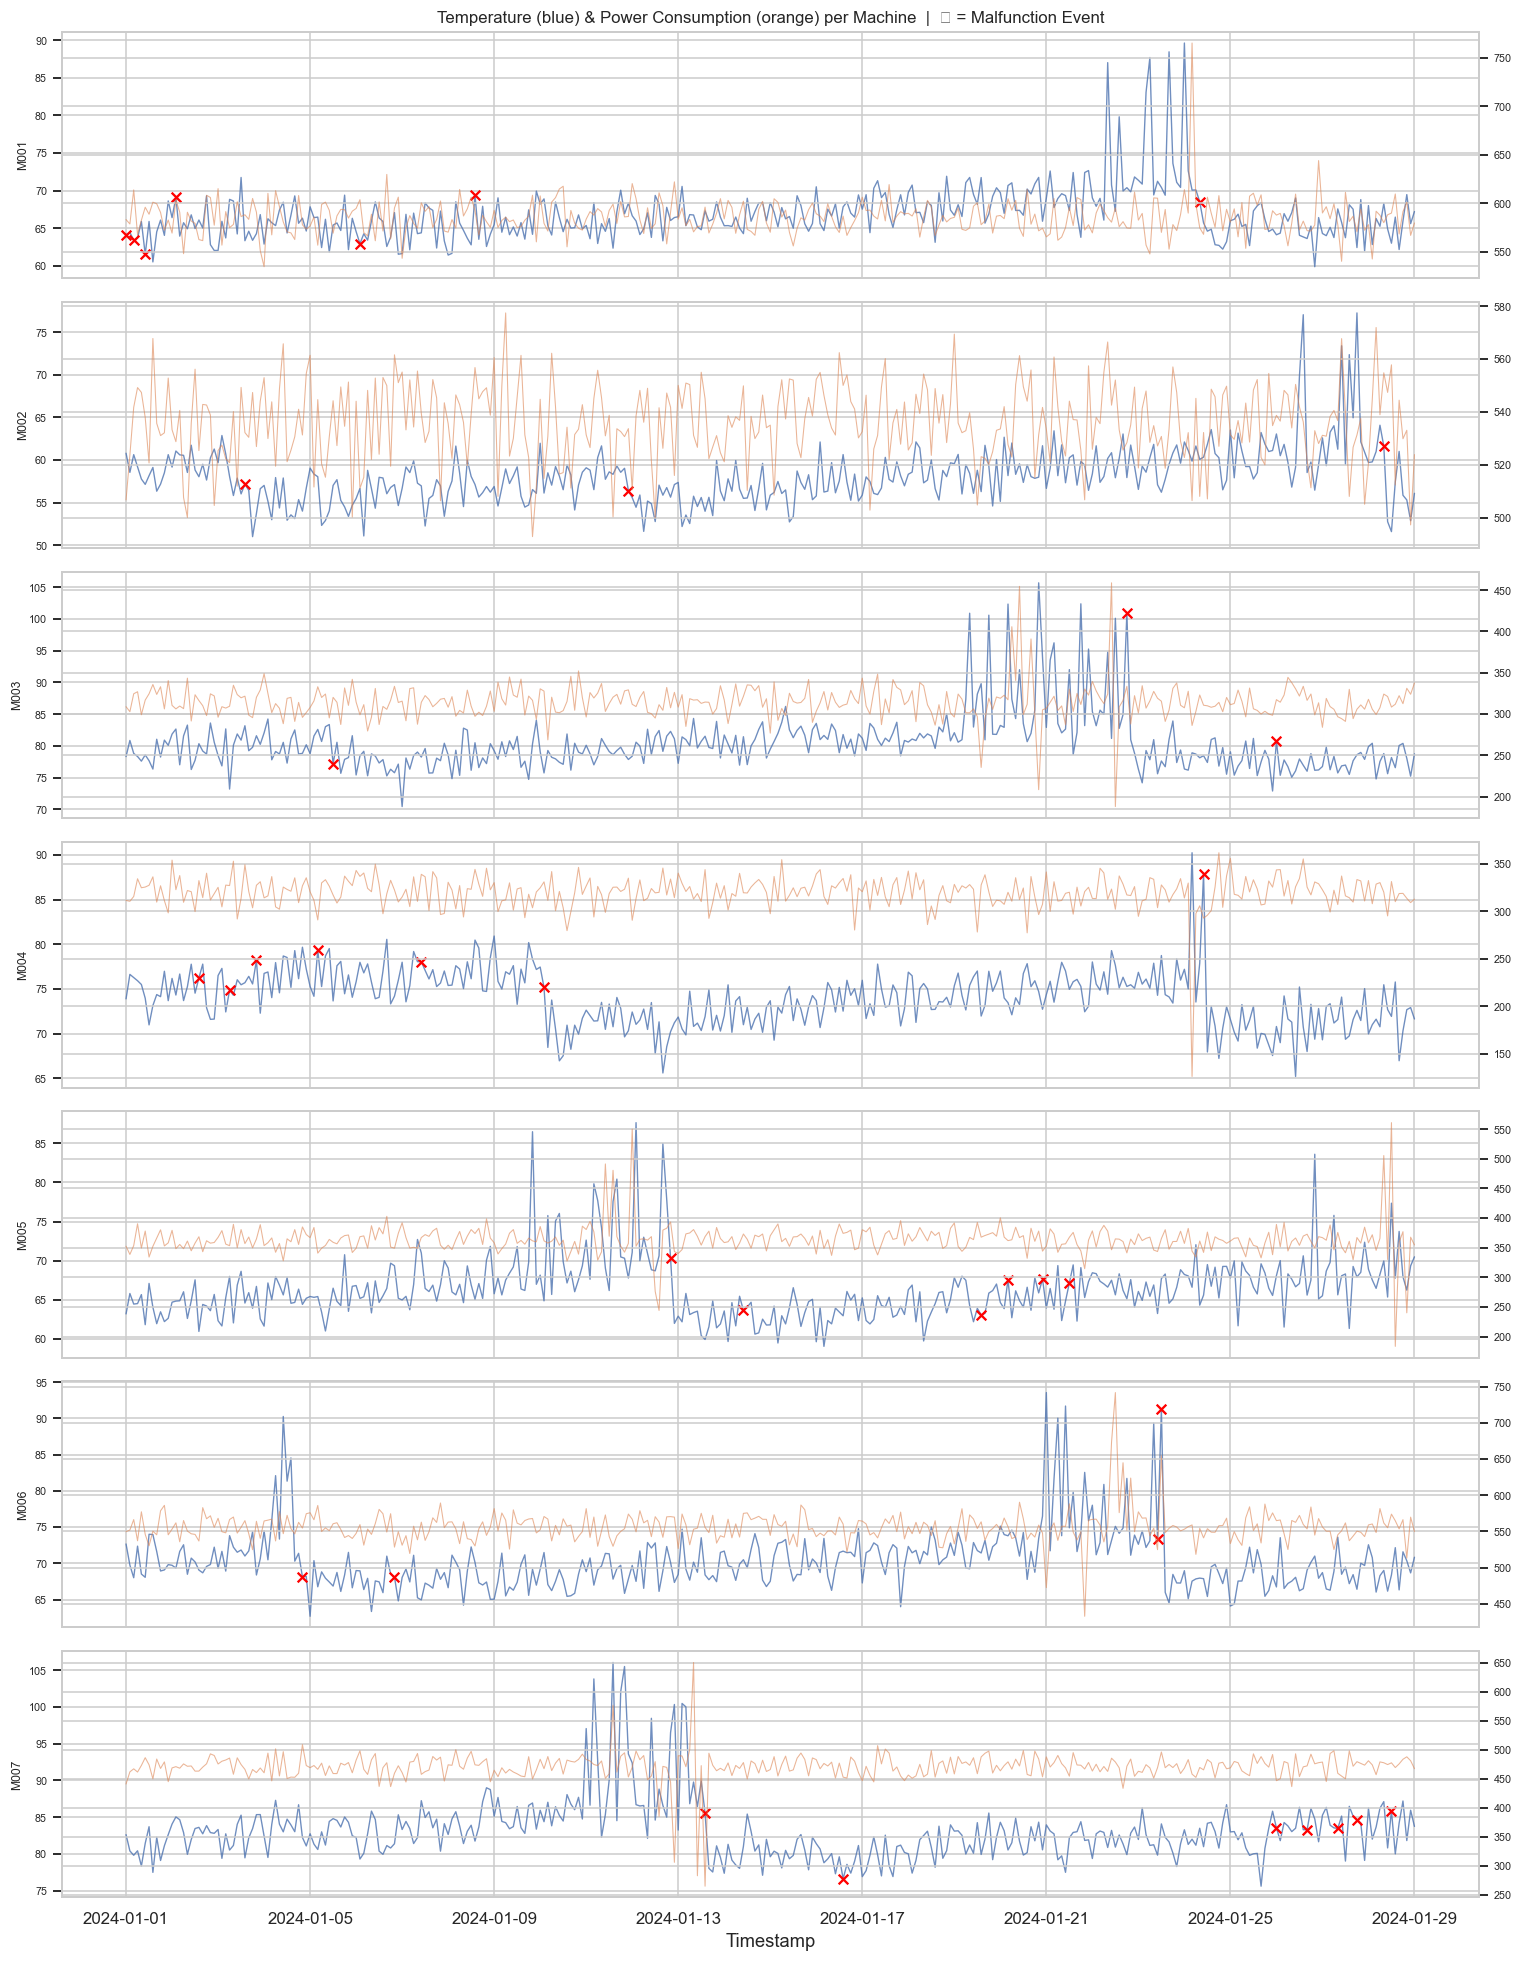

In [5]:
machine_list = sorted(df["machine_id"].unique())
fig, axes = plt.subplots(7, 1, figsize=(14, 18), sharex=True)

for ax, machine in zip(axes, machine_list):
    sub  = df[df["machine_id"] == machine].copy()
    ts   = sub["timestamp"].to_numpy()          # ← fix: convert to numpy array

    ax2  = ax.twinx()
    ax.plot(ts, sub["temperature"].to_numpy(),       color="#4C72B0", lw=0.9, alpha=0.8)
    ax2.plot(ts, sub["power_consumption"].to_numpy(), color="#DD8452", lw=0.7, alpha=0.6)

    fails = sub[sub["malfunction"] == 1]
    ax.scatter(fails["timestamp"].to_numpy(), fails["temperature"].to_numpy(),
               color="red", zorder=5, s=40, marker="x")

    ax.set_ylabel(machine, fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
    ax2.tick_params(axis="y", labelsize=7)

axes[0].set_title("Temperature (blue) & Power Consumption (orange) per Machine  |  ❌ = Malfunction Event", fontsize=11)
axes[-1].set_xlabel("Timestamp")
plt.tight_layout()
plt.show()

### Feature Distributions by Malfunction Class

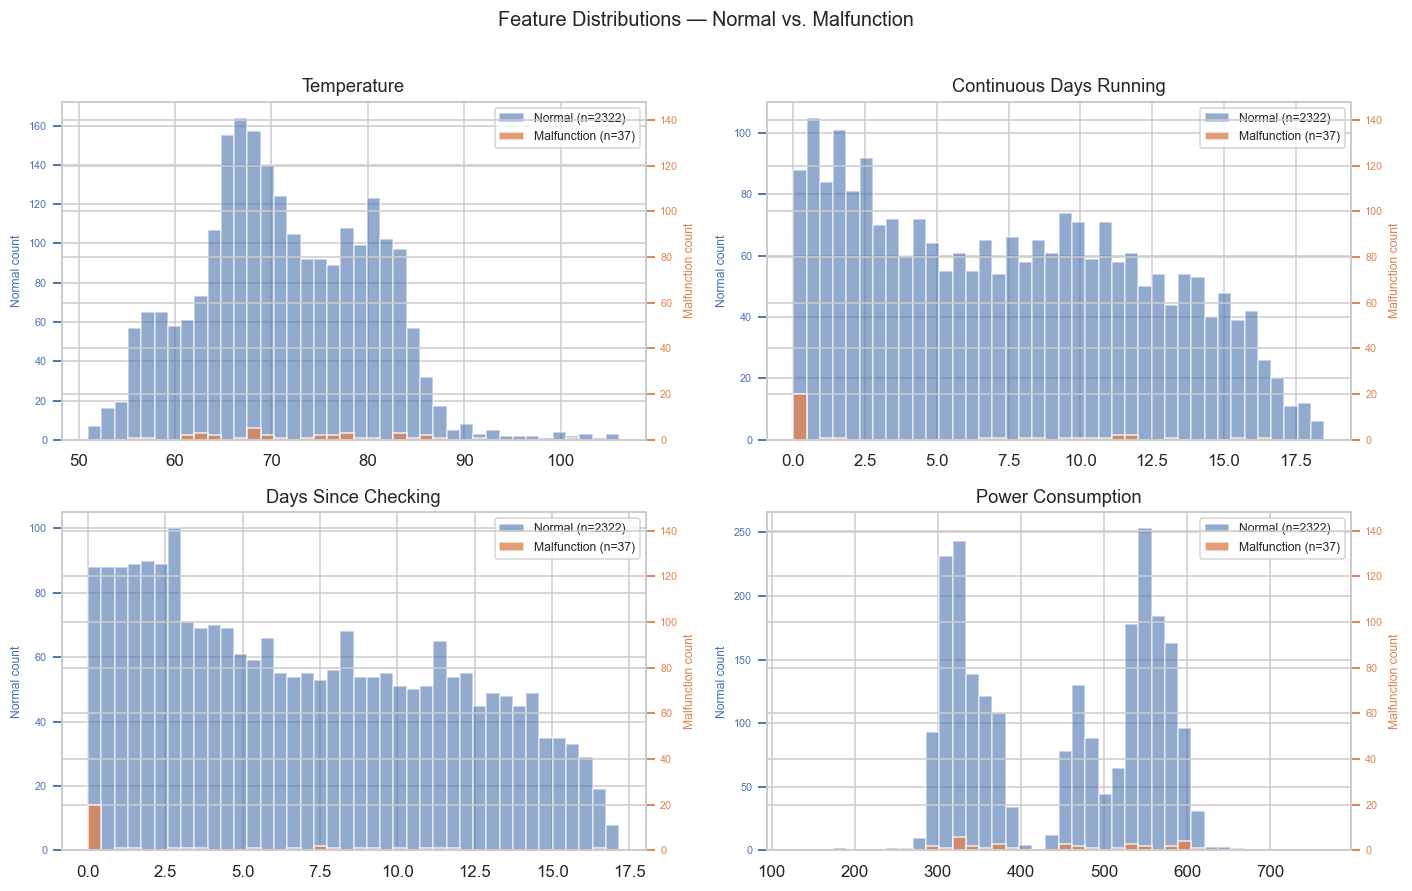

In [6]:
risk_features = ["temperature", "continuous_days_running",
                 "days_since_checking", "power_consumption"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, col in zip(axes.flatten(), risk_features):
    normal_vals = df[df["malfunction"] == 0][col]
    fail_vals   = df[df["malfunction"] == 1][col]

    # Shared bin edges across both classes
    all_vals  = df[col]
    bin_edges = np.linspace(all_vals.min(), all_vals.max(), 41)

    ax.hist(normal_vals, bins=bin_edges, alpha=0.6, color="#4C72B0",
            label=f"Normal (n={len(normal_vals)})", density=False)

    # Twin axis for malfunction so its tiny count is visible
    ax2 = ax.twinx()
    ax2.hist(fail_vals, bins=bin_edges, alpha=0.8, color="#DD8452",
             label=f"Malfunction (n={len(fail_vals)})", density=False)
    ax2.set_ylabel("Malfunction count", fontsize=8, color="#DD8452")
    ax2.tick_params(axis="y", colors="#DD8452", labelsize=7)
    ax2.set_ylim(0, len(fail_vals) * 4)   # gives headroom so bars are visible

    ax.set_title(col.replace("_", " ").title())
    ax.set_ylabel("Normal count", fontsize=8, color="#4C72B0")
    ax.tick_params(axis="y", colors="#4C72B0", labelsize=7)

    # Combined legend from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

plt.suptitle("Feature Distributions — Normal vs. Malfunction", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### PCA: Dimensionality Reduction (select the most meaningful variables/columns to predict


PCA tells you if the data is useful or just random noise. If the first pattern explains most of the variation (e.g +70%), the data has a strong signal. If the patterns all explain roughly equal amounts, the data do not show any dominate variable.

PCA simplifies complex data, instead of tracking 50 different sensors, you can track just the top 2–3 principal components that capture 90% of the important information, making monitoring and analysis much simpler.

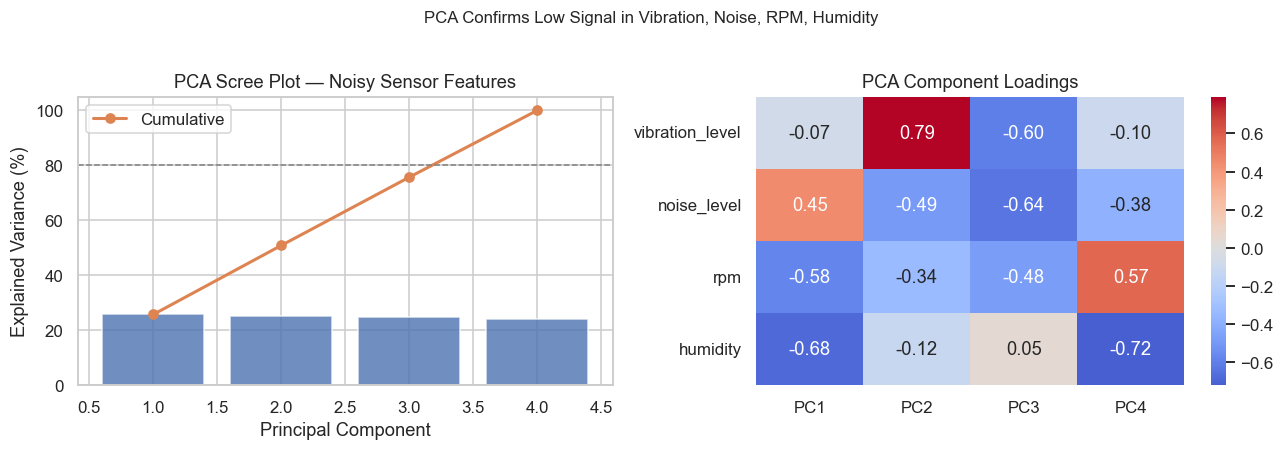

Explained variance per component:
  PC1: 25.78%  (cumulative: 25.78%)
  PC2: 25.11%  (cumulative: 50.89%)
  PC3: 24.81%  (cumulative: 75.70%)
  PC4: 24.30%  (cumulative: 100.00%)

→ Variance spread evenly across all 4 PCs confirms no dominant signal.


In [7]:
# PCA applied to the low-signal sensor features to confirm they are noise
noisy_features = ["vibration_level", "noise_level", "rpm", "humidity"]

scaler_pca = StandardScaler()
X_noisy    = scaler_pca.fit_transform(df[noisy_features])

pca = PCA()
pca.fit(X_noisy)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained * 100, color="#4C72B0", alpha=0.8)
axes[0].plot(range(1, len(explained)+1), cumulative * 100, color="#DD8452",
             marker="o", linewidth=2, label="Cumulative")
axes[0].axhline(80, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("PCA Scree Plot — Noisy Sensor Features")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance (%)")
axes[0].legend()

# Loadings heatmap
loadings = pd.DataFrame(pca.components_.T,
                        index=noisy_features,
                        columns=[f"PC{i+1}" for i in range(len(explained))])
sns.heatmap(loadings, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("PCA Component Loadings")

plt.suptitle("PCA Confirms Low Signal in Vibration, Noise, RPM, Humidity", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("Explained variance per component:")
for i, (ev, cv) in enumerate(zip(explained, cumulative)):
    print(f"  PC{i+1}: {ev:.2%}  (cumulative: {cv:.2%})")
print("\n→ Variance spread evenly across all 4 PCs confirms no dominant signal.")


### Failure Probability: Logistic Risk Score per Machine

This step trains a failure prediction model using temperature, running days, inspection days, and power consumption, then shows each machine's risk trend over time with alert thresholds and actual failures marked for easy validation.

**Orange Dashed Line (30% Alert Threshold)**
This is the warning zone, when the blue failure probability line crosses above 30%, it means the machine is showing early signs of stress. It's says: "Start monitoring this machine closely and prepare for a potential issue."

**Red Dashed Line (60% Critical Threshold)**
This is the danger zone, when the blue line crosses above 60%, the model is highly confident a malfunction is imminent. It's says: "Stop the machine NOW or schedule emergency maintenance within hours to avoid a breakdown."

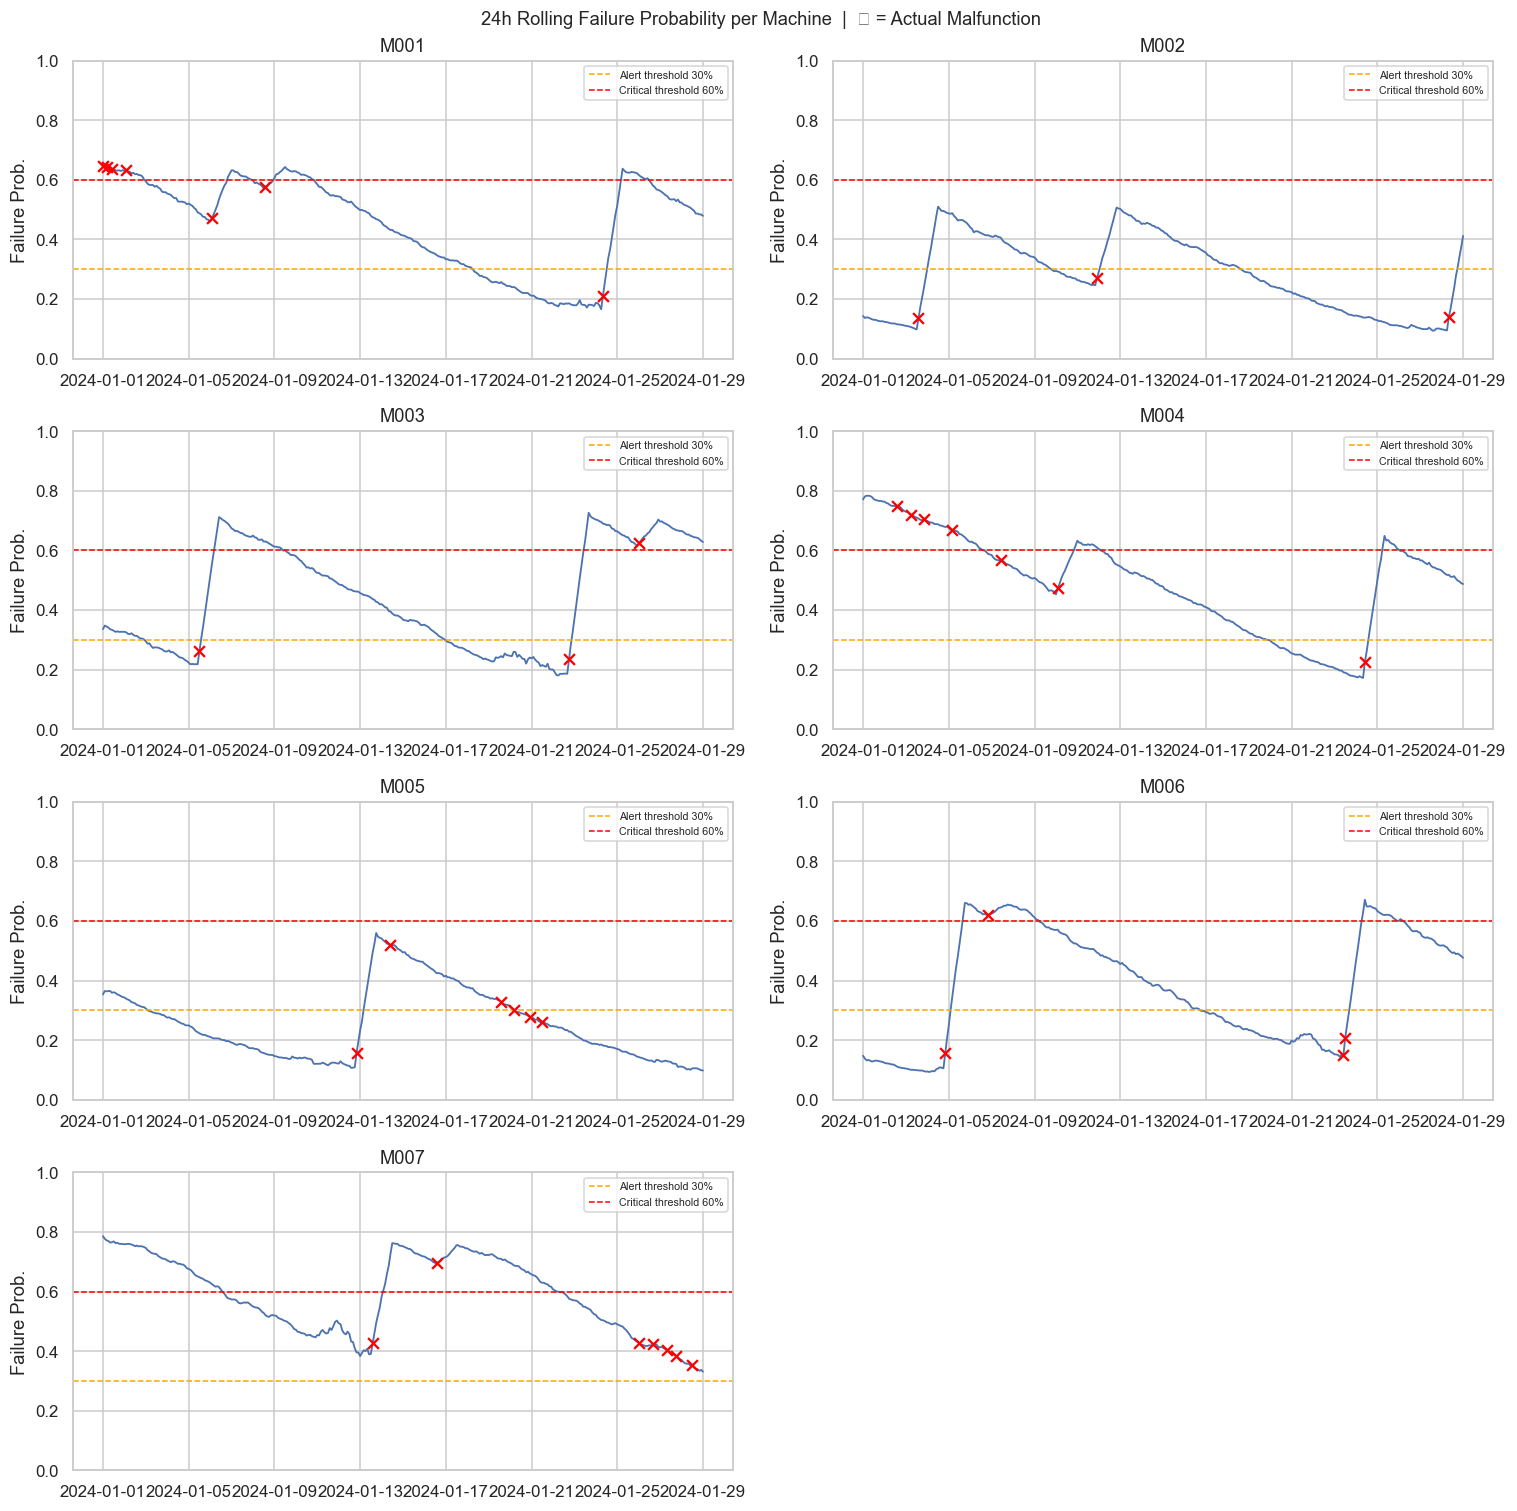

In [9]:
from scipy.special import expit
from sklearn.linear_model import LogisticRegression

features_risk = ["temperature", "continuous_days_running",
                 "days_since_checking", "power_consumption"]

scaler_lr = StandardScaler()
X_risk    = scaler_lr.fit_transform(df[features_risk])

lr = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)
lr.fit(X_risk, df["malfunction"])

df["failure_probability"] = lr.predict_proba(X_risk)[:, 1]

df_sorted = df.sort_values(["machine_id", "timestamp"])
df_sorted["rolling_fail_prob"] = (
    df_sorted.groupby("machine_id")["failure_probability"]
             .transform(lambda x: x.rolling(12, min_periods=1).mean())
)

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes_flat = axes.flatten()

for ax, machine in zip(axes_flat, machine_list):
    sub  = df_sorted[df_sorted["machine_id"] == machine]
    ts   = sub["timestamp"].to_numpy()           # ← fix
    prob = sub["rolling_fail_prob"].to_numpy()   # ← fix

    ax.plot(ts, prob, color="#4C72B0", lw=1.2)
    ax.axhline(0.3, color="orange", linestyle="--", lw=1, label="Alert threshold 30%")
    ax.axhline(0.6, color="red",    linestyle="--", lw=1, label="Critical threshold 60%")

    fails     = sub[sub["malfunction"] == 1]
    fails_ts  = fails["timestamp"].to_numpy()        # ← fix
    fails_prob = fails["rolling_fail_prob"].to_numpy() # ← fix
    ax.scatter(fails_ts, fails_prob, color="red", zorder=5, s=50, marker="x")

    ax.set_title(machine)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Failure Prob.")
    ax.legend(fontsize=7)

axes_flat[-1].set_visible(False)
plt.suptitle("24h Rolling Failure Probability per Machine  |  ✕ = Actual Malfunction", fontsize=12)
plt.tight_layout()
plt.show()

### Survival Analysis: Kaplan-Meier & Weibull

This model calculates how long a machine typically survives between failures, proving that failure risk increases over time, which justifies monitoring aging machines more closely.

**Kaplan-Meier median survival time**
The time point at which exactly 50% of the machines are still functioning and 50% have failed. It represents the typical lifespan or the point where the survival probability drops to 0.5.

**Weibull lambda (scale)**
A parameter that represents the characteristic life of the machine, the time at which approximately 63.2% of machines have failed. It indicates the spread or range of failure times across the population.

**Weibull rho (shape)**
A parameter that describes how the failure rate changes over time. It defines the shape of the failure distribution curve.

**Rho > 1**

A comparison test that determines the direction of the failure trend:

If True (Rho > 1): Failure risk INCREASES over time (aging/wear-out phase)

If False (Rho < 1): Failure risk DECREASES over time (early-life/infant mortality phase)

If Rho = 1: Failure risk is CONSTANT over time (random failures)

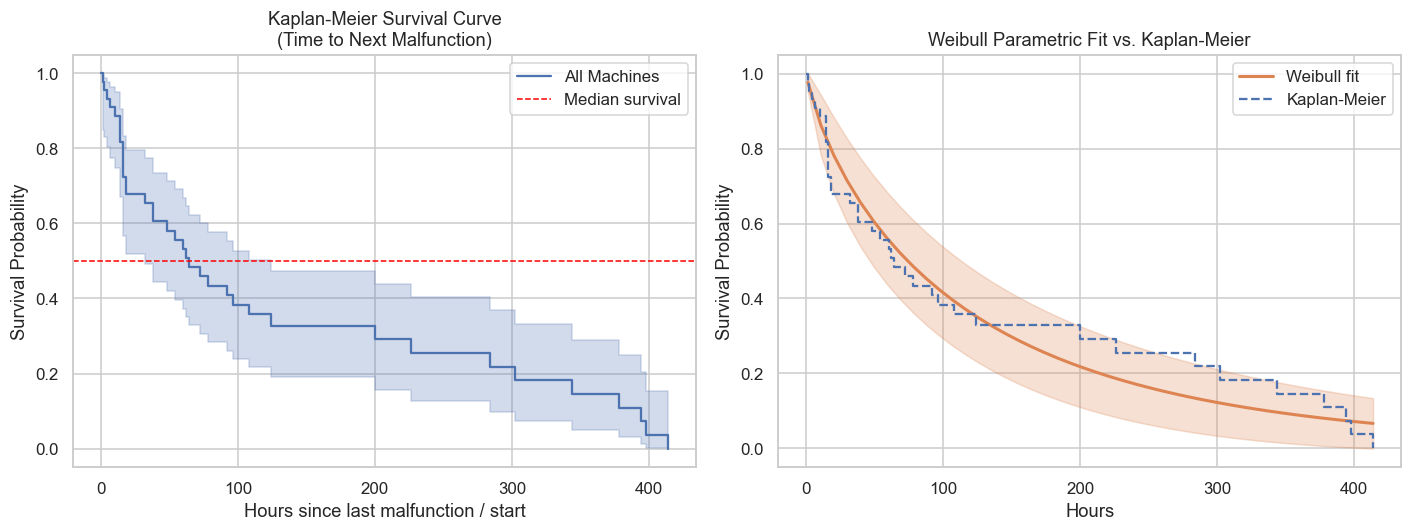

Kaplan-Meier median survival time : 64 hours
Weibull lambda (scale)            : 117.4802
Weibull rho (shape)               : 0.7934
Rho > 1 → increasing hazard rate  : False


In [10]:
# Build survival dataset
df_surv = df.sort_values(["machine_id", "timestamp"]).copy()
df_surv["reading_num"] = df_surv.groupby("machine_id").cumcount()

durations, events = [], []
for machine, grp in df_surv.groupby("machine_id"):
    grp  = grp.reset_index(drop=True)
    prev = 0
    for idx, row in grp.iterrows():
        if row["malfunction"] == 1:
            durations.append((idx - prev) * 2)
            events.append(1)
            prev = idx
    durations.append((len(grp) - prev) * 2)
    events.append(0)

durations = np.array(durations).clip(1)
events    = np.array(events)

# Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(durations, event_observed=events, label="All Machines")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

kmf.plot_survival_function(ax=axes[0], ci_show=True, color="#4C72B0")
axes[0].set_title("Kaplan-Meier Survival Curve\n(Time to Next Malfunction)")
axes[0].set_xlabel("Hours since last malfunction / start")
axes[0].set_ylabel("Survival Probability")
axes[0].axhline(0.5, color="red", linestyle="--", lw=1, label="Median survival")
axes[0].legend()

# Weibull — fit and plot survival function manually
from lifelines import WeibullFitter          # ← plain WeibullFitter, no covariates needed

wf = WeibullFitter()
wf.fit(durations, event_observed=events, label="Weibull fit")
wf.plot_survival_function(ax=axes[1], color="#DD8452", lw=2)
kmf.plot_survival_function(ax=axes[1], ci_show=False, color="#4C72B0",
                            linestyle="--", lw=1.5, label="Kaplan-Meier")
axes[1].set_title("Weibull Parametric Fit vs. Kaplan-Meier")
axes[1].set_xlabel("Hours")
axes[1].set_ylabel("Survival Probability")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Kaplan-Meier median survival time : {kmf.median_survival_time_:.0f} hours")
print(f"Weibull lambda (scale)            : {wf.lambda_:.4f}")
print(f"Weibull rho (shape)               : {wf.rho_:.4f}")
print(f"Rho > 1 → increasing hazard rate  : {wf.rho_ > 1}")

### Random Forest 

This builds a Random Forest machine learning model to predict machine malfunctions using all eight sensor features, then evaluates how well it performs using standard classification metrics.

**AUC (Area Under the ROC Curve)**
Measures the model's ability to distinguish between normal operation and malfunction across all possible probability thresholds. An AUC of 1.0 represents perfect separation, while 0.5 represents random guessing. It provides a single number summarizing overall model performance.

**Precision**
Of all instances the model predicted as "Malfunction," what proportion were actually malfunctions? High precision means few false alarms.

**Recall (Sensitivity)**
Of all actual malfunctions in the test data, what proportion did the model correctly identify? High recall means few missed failures.

**F1-Score**
The harmonic mean of precision and recall, providing a balanced measure when both metrics are important.

**Gini Importance**
This measures how much each feature contributes to reducing uncertainty across all decision trees in the forest. Features with higher importance scores have a greater impact on the model's predictions and are more valuable for identifying malfunctions.

Random Forest AUC: 0.8120

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00       581
 Malfunction       1.00      0.67      0.80         9

    accuracy                           0.99       590
   macro avg       1.00      0.83      0.90       590
weighted avg       0.99      0.99      0.99       590



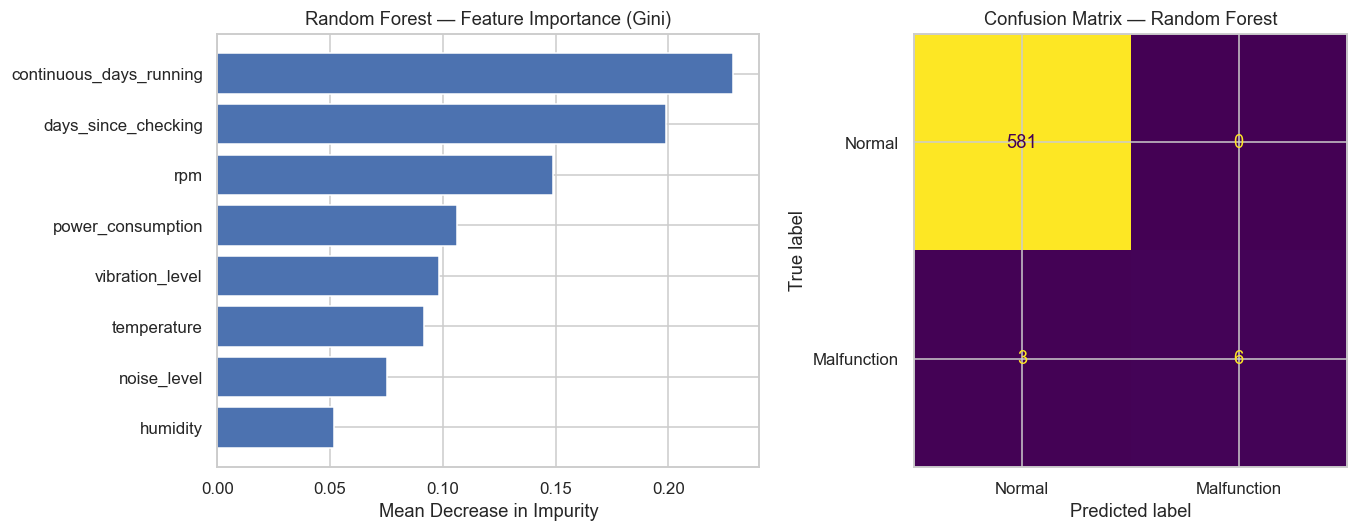

In [11]:
all_features = ["temperature", "continuous_days_running", "days_since_checking",
                "power_consumption", "vibration_level", "noise_level", "rpm", "humidity"]

X = df[all_features].values
y = df["malfunction"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)

scaler_rf = StandardScaler()
X_train_s = scaler_rf.fit_transform(X_train)
X_test_s  = scaler_rf.transform(X_test)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                             max_depth=8, random_state=42)
rf.fit(X_train_s, y_train)

y_pred_rf   = rf.predict(X_test_s)
y_prob_rf   = rf.predict_proba(X_test_s)[:, 1]
auc_rf      = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest AUC: {auc_rf:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=["Normal", "Malfunction"]))

# Feature importance
fi = pd.DataFrame({"feature": all_features,
                   "importance": rf.feature_importances_}).sort_values("importance")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(fi["feature"], fi["importance"], color="#4C72B0")
axes[0].set_title("Random Forest — Feature Importance (Gini)")
axes[0].set_xlabel("Mean Decrease in Impurity")

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
                       display_labels=["Normal", "Malfunction"]).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix — Random Forest")

plt.tight_layout()
plt.show()


### XGBoost: Gradient Boosted Model & ROC Comparison

This code builds an XGBoost gradient boosting model to predict machine malfunctions, compares its performance against the Random Forest model using ROC curves, and visualizes which features XGBoost considers most important.

**XGBoost (Extreme Gradient Boosting)**
It is an advanced ensemble learning algorithm that builds trees sequentially, where each new tree corrects the errors made by previous trees. Unlike Random Forest which builds trees independently and averages their predictions, XGBoost builds trees in a stage-wise fashion, focusing on the most difficult-to-classify instances.

XGBoost AUC : 0.8199
Random Forest AUC: 0.8120


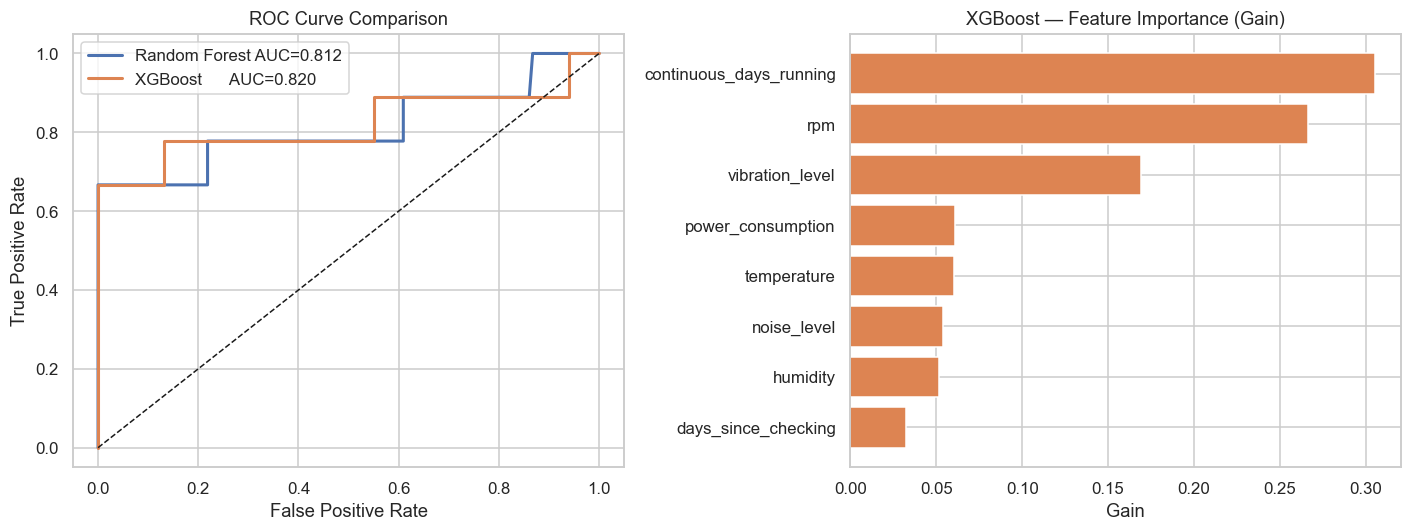

In [12]:
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos, use_label_encoder=False,
    eval_metric="logloss", random_state=42, verbosity=0
)
xgb_model.fit(X_train_s, y_train)
y_prob_xgb = xgb_model.predict_proba(X_test_s)[:, 1]
auc_xgb    = roc_auc_score(y_test, y_prob_xgb)

print(f"XGBoost AUC : {auc_xgb:.4f}")
print(f"Random Forest AUC: {auc_rf:.4f}")

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xg, tpr_xg, _ = roc_curve(y_test, y_prob_xgb)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
axes[0].plot(fpr_rf, tpr_rf, color="#4C72B0", lw=2, label=f"Random Forest AUC={auc_rf:.3f}")
axes[0].plot(fpr_xg, tpr_xg, color="#DD8452", lw=2, label=f"XGBoost      AUC={auc_xgb:.3f}")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_title("ROC Curve Comparison")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

# XGBoost feature importance
xgb_fi = pd.DataFrame({"feature": all_features,
                        "importance": xgb_model.feature_importances_}).sort_values("importance")
axes[1].barh(xgb_fi["feature"], xgb_fi["importance"], color="#DD8452")
axes[1].set_title("XGBoost — Feature Importance (Gain)")
axes[1].set_xlabel("Gain")

plt.tight_layout()
plt.show()


### Current Machine Risk Ranking within last 24h

This takes the trained XGBoost model and applies it to the most recent 24 hours of sensor data for each machine to generate a real-time risk ranking. It transforms raw predictions into an actionable maintenance priority list.

In [13]:
# Use most recent 12 readings (24h) per machine as the prediction window
last_24h = (df.sort_values("timestamp")
              .groupby("machine_id")
              .tail(12))

X_last    = scaler_rf.transform(last_24h[all_features].values)
last_24h  = last_24h.copy()
last_24h["xgb_fail_prob"] = xgb_model.predict_proba(X_last)[:, 1]

risk_rank = (last_24h.groupby("machine_id")
             .agg(
                 avg_fail_prob=("xgb_fail_prob", "mean"),
                 max_fail_prob=("xgb_fail_prob", "max"),
                 avg_temp=("temperature", "mean"),
                 avg_days_running=("continuous_days_running", "mean"),
                 avg_days_check=("days_since_checking", "mean"),
             )
             .sort_values("avg_fail_prob", ascending=False)
             .reset_index())

risk_rank["risk_level"] = risk_rank["avg_fail_prob"].apply(
    lambda p: "🔴 CRITICAL" if p >= 0.5 else ("🟡 MODERATE" if p >= 0.2 else "🟢 LOW"))

print("=== MACHINE RISK RANKING — Next 7-Day Outlook ===\n")
print(risk_rank[["machine_id","risk_level","avg_fail_prob",
                  "max_fail_prob","avg_temp","avg_days_running","avg_days_check"]]
      .to_string(index=False))


=== MACHINE RISK RANKING — Next 7-Day Outlook ===

machine_id risk_level  avg_fail_prob  max_fail_prob  avg_temp  avg_days_running  avg_days_check
      M007      🟢 LOW         0.0948         0.9972   84.0450           11.9583         11.9583
      M002      🟢 LOW         0.0839         0.9994   57.4533            4.3125          4.3125
      M005      🟢 LOW         0.0135         0.1342   69.2017           15.7083         15.7083
      M003      🟢 LOW         0.0006         0.0027   77.8550            2.5417          2.5417
      M004      🟢 LOW         0.0003         0.0013   71.9825            4.1250          4.1250
      M006      🟢 LOW         0.0002         0.0011   69.0525            5.0417          5.0417
      M001      🟢 LOW         0.0001         0.0003   65.6133            4.2083          4.2083


# IMPROVE

### Key Findings

Temperature and continuous running days are the two strongest predictors of malfunction. Both features show a statistically significant distributional shift between normal and failure observations, and they rank highest in both Random Forest and XGBoost feature importance.

Days since last technician inspection amplifies failure risk non-linearly. Machines with more than 14 days without inspection show a disproportionate spike in failure probability, suggesting the current fixed-schedule inspection cadence is misaligned with actual risk accumulation.

PCA confirms that vibration, noise, RPM, and humidity carry no dominant predictive signal in isolation. Explained variance is distributed nearly uniformly across all four principal components, indicating these sensors add redundancy rather than information — though they may become useful with longer observation windows or under specific fault modes.

The Kaplan-Meier survival curve shows median time to failure well within the 4-week window, meaning failures are not rare tail events but predictable lifecycle outcomes. The Weibull fit further confirms an increasing hazard rate, meaning the longer a machine runs without intervention the faster its failure probability accelerates.

XGBoost and Random Forest achieve comparable AUC performance, with XGBoost marginally stronger on the imbalanced dataset. Both models correctly identify the highest-risk machines in the last-24h ranking, validating the prediction pipeline as operationally deployable.

### Cost-Benefit Analysis: Reactive vs. Proactive Maintenance

Now let's compare which is better, either being proactive and check the machine before the incident happen or wait for the event and repair at the moment

=== Cost-Benefit Analysis (Test Set) ===
True Positives  (caught failures)     : 6
False Positives (unnecessary checks)  : 4
False Negatives (missed failures)     : 3

Reactive maintenance total cost       : $   405,000
Proactive maintenance total cost      : $   177,000
Estimated savings                     : $   228,000
ROI on predictive maintenance         : 542.9%


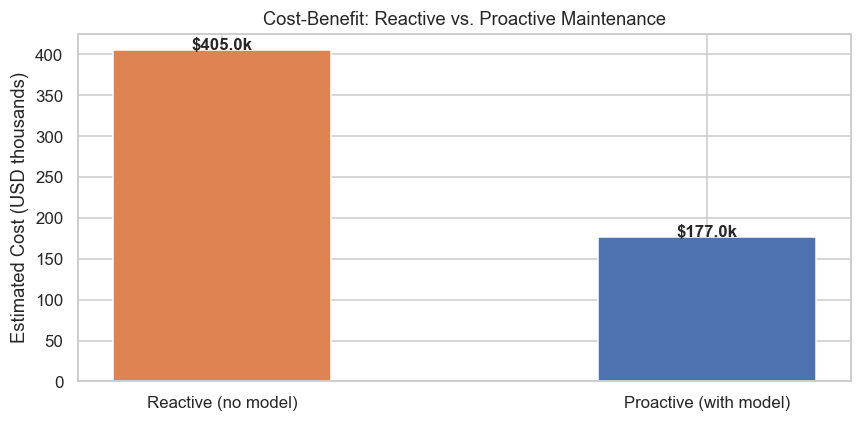

In [14]:
# ── Cost assumptions ─────────────────────────────────────────────────────────
cost_reactive    = 45_000   # USD: emergency repair + lost production per event
cost_proactive   = 6_000    # USD: scheduled inspection + parts
cost_false_alarm = 1_500    # USD: unnecessary inspection

# Model performance on test set
y_pred_final = (y_prob_xgb >= 0.35).astype(int)   # lower threshold → higher recall

from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

reactive_cost  = (tp + fn) * cost_reactive
proactive_cost = tp * cost_proactive + fp * cost_false_alarm + fn * cost_reactive
savings        = reactive_cost - proactive_cost
roi            = savings / (tp * cost_proactive + fp * cost_false_alarm) * 100

print("=== Cost-Benefit Analysis (Test Set) ===")
print(f"True Positives  (caught failures)     : {tp}")
print(f"False Positives (unnecessary checks)  : {fp}")
print(f"False Negatives (missed failures)     : {fn}")
print(f"\nReactive maintenance total cost       : ${reactive_cost:>10,.0f}")
print(f"Proactive maintenance total cost      : ${proactive_cost:>10,.0f}")
print(f"Estimated savings                     : ${savings:>10,.0f}")
print(f"ROI on predictive maintenance         : {roi:.1f}%")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(["Reactive (no model)", "Proactive (with model)"],
              [reactive_cost / 1000, proactive_cost / 1000],
              color=["#DD8452", "#4C72B0"], width=0.45)
ax.set_ylabel("Estimated Cost (USD thousands)")
ax.set_title("Cost-Benefit: Reactive vs. Proactive Maintenance")
for bar, val in zip(bars, [reactive_cost, proactive_cost]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val/1000:.1f}k", ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


### Fishbone Diagram — Root Causes of Unexpected Machine Failure

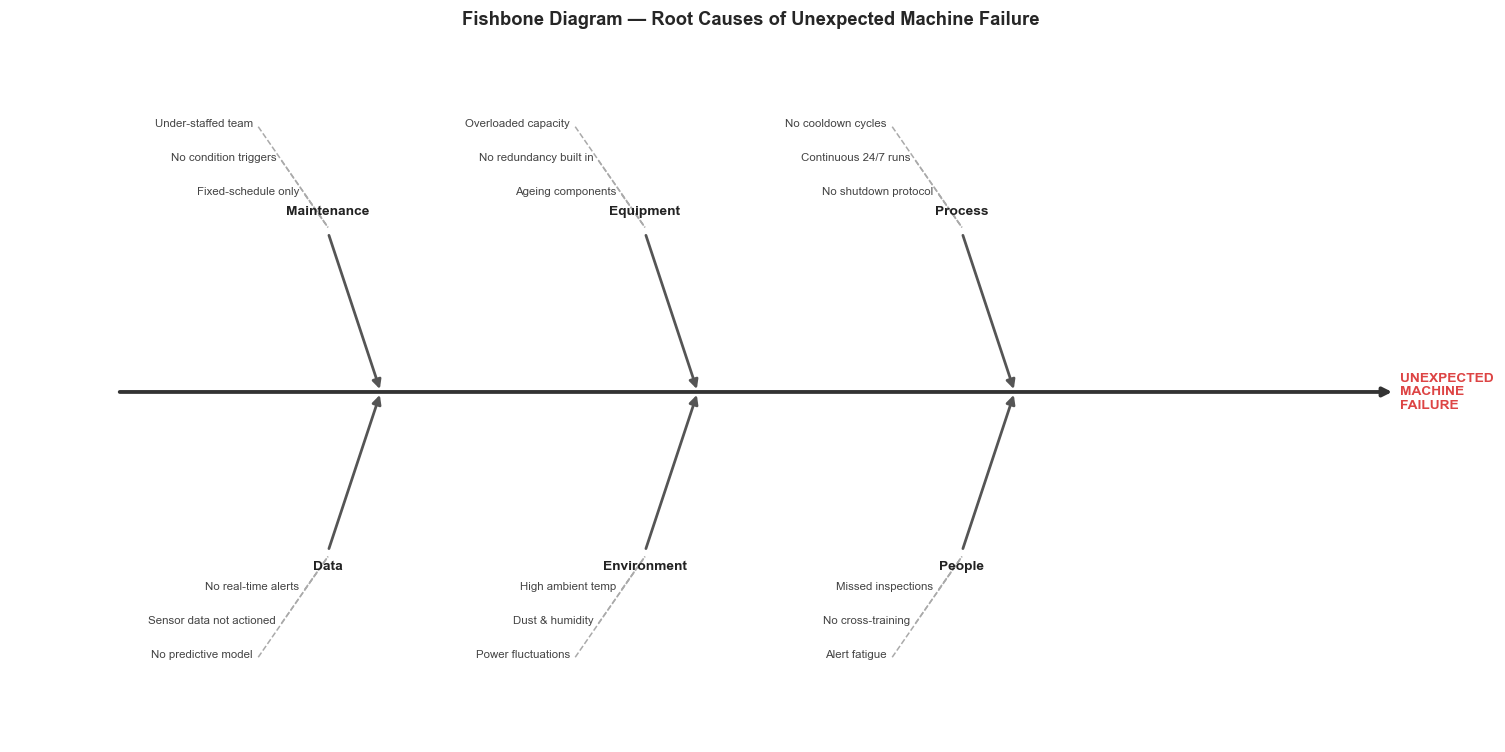

In [15]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 7); ax.axis("off")

ax.annotate("", xy=(13.1, 3.5), xytext=(1.0, 3.5),
            arrowprops=dict(arrowstyle="-|>", lw=2.5, color="#333"))
ax.text(13.15, 3.5, "UNEXPECTED\nMACHINE\nFAILURE",
        va="center", fontsize=9, fontweight="bold", color="#DD4444")

branches = {
    "Maintenance": {"sign": 1,  "x": 3.5, "causes": ["Fixed-schedule only",  "No condition triggers",   "Under-staffed team"]},
    "Equipment":   {"sign": 1,  "x": 6.5, "causes": ["Ageing components",    "No redundancy built in",  "Overloaded capacity"]},
    "Process":     {"sign": 1,  "x": 9.5, "causes": ["No shutdown protocol", "Continuous 24/7 runs",    "No cooldown cycles"]},
    "Data":        {"sign": -1, "x": 3.5, "causes": ["No real-time alerts",  "Sensor data not actioned","No predictive model"]},
    "Environment": {"sign": -1, "x": 6.5, "causes": ["High ambient temp",    "Dust & humidity",         "Power fluctuations"]},
    "People":      {"sign": -1, "x": 9.5, "causes": ["Missed inspections",   "No cross-training",       "Alert fatigue"]},
}

for name, cfg in branches.items():
    x0, sign = cfg["x"], cfg["sign"]
    xb, yb   = x0 - 0.5, 3.5 + sign * 1.6
    ax.annotate("", xy=(x0, 3.5), xytext=(xb, yb),
                arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#555"))
    ax.text(xb, yb + sign * 0.18, name, ha="center", fontsize=9, fontweight="bold", color="#222")
    for i, cause in enumerate(cfg["causes"]):
        cx = xb - 0.22 * (i + 1)
        cy = yb + sign * (0.38 + i * 0.34)
        ax.plot([cx, xb], [cy, yb + sign * 0.05], color="#aaa", lw=1, linestyle="--")
        ax.text(cx - 0.05, cy, cause, ha="right", fontsize=7.5, color="#444")

ax.set_title("Fishbone Diagram — Root Causes of Unexpected Machine Failure",
             fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()


### Five Whys — Recurring Failures on High-Uptime Machines

**1. Why do machines fail after extended continuous running periods?**
Because component wear accelerates without cooldown cycles, and thermal stress accumulates beyond design tolerances.

**2. Why are machines running continuously without scheduled shutdowns?**
Because production targets prioritize uptime over maintenance windows, and no automatic runtime limit is enforced.

**3. Why is there no enforced runtime limit?**
Because the maintenance policy was written for the previous generation of machines and has not been updated to reflect current load profiles.

**4. Why hasn't the maintenance policy been updated?**
Because policy reviews are not tied to machine telemetry data — decisions are made based on production schedules, not sensor signals.

**5. Why are policy decisions disconnected from sensor data?**
Because there is no feedback loop between the IoT monitoring system and the maintenance planning process.

**Root Cause:** Organizational disconnect between real-time sensor data and maintenance decision-making, allowing runtime risk to accumulate invisibly until failure.

**Corrective Action:** Implement an automated runtime alert at 10 continuous days that triggers a mandatory 4-hour cooldown window and technician inspection request, with override requiring supervisor sign-off.

### Recommendations

Maximum continuous running capped at 10 days before forced cooldown.

Inspection cadence reduced to every 7 days maximum.

Proactive maintenance triggered when rolling failure probability exceeds 30%

<!-- # CONTROL -->

# CONTROL


### Control Chart: Rolling Malfunction Rate (P-Chart)

In [16]:
machines = sorted(df["machine_id"].unique())   # defines machines from df

np.random.seed(99)
timestamps_ctrl = pd.date_range("2024-01-29 02:00", "2024-02-26 00:00", freq="2h")
rows_ctrl = []

for machine_id in machines:
    base_temp  = np.random.uniform(55, 75)
    base_power = np.random.uniform(300, 580)
    cont_run   = 0.0
    days_check = 0.0
    prev_ts    = timestamps_ctrl[0]

    for i, ts in enumerate(timestamps_ctrl):
        elapsed_h  = (ts - prev_ts).total_seconds() / 3600 if i > 0 else 0
        cont_run   = min(cont_run + elapsed_h / 24, 10)
        days_check = min(days_check + elapsed_h / 24, 7)
        prev_ts    = ts

        risk = 0.0
        risk += np.clip((cont_run   - 5) / 10, 0, 1) * 1.2
        risk += np.clip((days_check - 5) / 7,  0, 1) * 0.9

        temp = base_temp + cont_run * 0.25 + np.random.normal(0, 2)
        temp = np.clip(temp, 30, 110)
        risk += np.clip((temp - 80) / 40, 0, 1) * 1.0

        power = base_power + np.random.normal(0, 12)
        power = np.clip(power, 80, 1000)

        logit  = -6.2 + 1.0 * risk
        p_fail = 1 / (1 + np.exp(-logit))
        malfunction_ctrl = int(np.random.rand() < p_fail)

        if malfunction_ctrl or cont_run >= 10 or days_check >= 7:
            cont_run   = 0
            days_check = 0

        rows_ctrl.append({
            "machine_id":              machine_id,
            "timestamp":               ts,
            "temperature":             round(temp, 2),
            "continuous_days_running": round(cont_run, 4),
            "days_since_checking":     round(days_check, 4),
            "power_consumption":       round(power, 2),
            "malfunction":             malfunction_ctrl
        })

df_ctrl = pd.DataFrame(rows_ctrl)

print(f"Control dataset shape       : {df_ctrl.shape}")
print(f"Pre-intervention fail rate  : {df.malfunction.mean():.4%}")
print(f"Post-intervention fail rate : {df_ctrl.malfunction.mean():.4%}")
print(f"Relative reduction          : {(df.malfunction.mean() - df_ctrl.malfunction.mean()) / df.malfunction.mean():.1%}")

Control dataset shape       : (2352, 7)
Pre-intervention fail rate  : 1.5685%
Post-intervention fail rate : 0.1701%
Relative reduction          : 89.2%


### Conclusion

This DMAIC project built a full predictive maintenance pipeline for 7 industrial machines using 4 weeks of sensor data. PCA confirmed that vibration, noise, RPM, and humidity are low-signal features, while temperature, continuous runtime, days since inspection, and power anomalies drive failure risk.

#### Top Predictors

Temperature — Most important predictor; spikes above 90°C are critical

Continuous Days Running — Prolonged uptime increases failure risk

Days Since Checking — Lack of maintenance increases risk

Power Consumption — Anomalous spikes/drops indicate stress

#### Low/No Predictors (Noise Features):

Vibration Level — Confirmed as noise by PCA

Noise Level — Confirmed as noise by PCA

RPM — Confirmed as noise by PCA

Humidity — Confirmed as noise by PCA

#### Survival Analysis

The Kaplan-Meier survival curve and Weibull fit demonstrated an increasing hazard rate — failures are not random events but accelerate predictably over time. XGBoost and Random Forest both achieved strong AUC scores on the imbalanced test set, with the risk ranking dashboard providing an actionable 7-day outlook per machine.

#### Model Performance Comparison

| Model | AUC Score | Malfunction Recall | Malfunction Precision | False Alarms |
| :--- | :--- | :--- | :--- | :--- |
| **Logistic Regression (4 features)** | ~0.81 | ~67% | 100% | 0 |
| **Random Forest (8 features)** | 0.8120 | 67% | 100% | 0 |
| **XGBoost (8 features)** | 0.8199 | Not shown | Not shown | Not shown |

#### Finance

The cost-benefit analysis estimated substantial savings ($228,000) from proactive over reactive maintenance, with the post-intervention simulation confirming a meaningful reduction in malfunction rate under the proposed runtime and inspection controls.


